In [2]:
#!pip install tensorflow

zsh:1: command not found: pip


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import os
import json
import joblib

In [2]:
base_path = "/Users/sourabh18/Desktop/Projects"
save_path = f"{base_path}/artifacts"
os.makedirs(save_path, exist_ok=True)

X_train_scaled_df = pd.read_pickle(f"{base_path}/X_train_scaled.pkl")
X_test_scaled_df = pd.read_pickle(f"{base_path}/X_test_scaled.pkl")
X_faulty_scaled_df = pd.read_pickle(f"{base_path}/X_faulty_scaled.pkl")

train_meta = pd.read_pickle(f"{base_path}/train_meta.pkl")
test_meta = pd.read_pickle(f"{base_path}/test_meta.pkl")
faulty_meta = pd.read_pickle(f"{base_path}/faulty_meta.pkl")

cols_to_drop = ["faultNumber", "faultNumber_rollmean", "faultNumber_diff"]

X_train_scaled_df = X_train_scaled_df.drop(columns=cols_to_drop, errors="ignore")
X_test_scaled_df = X_test_scaled_df.drop(columns=cols_to_drop, errors="ignore")
X_faulty_scaled_df = X_faulty_scaled_df.drop(columns=cols_to_drop, errors="ignore")

print("X_train_scaled_df shape:", X_train_scaled_df.shape)
print("X_test_scaled_df shape:", X_test_scaled_df.shape)
print("X_faulty_scaled_df shape:", X_faulty_scaled_df.shape)
print("train_meta shape:", train_meta.shape)
print("test_meta shape:", test_meta.shape)
print("faulty_meta shape:", faulty_meta.shape)

print("Fault columns in train:", [c for c in X_train_scaled_df.columns if "fault" in c.lower()])

X_train_scaled_df shape: (250000, 156)
X_test_scaled_df shape: (480000, 156)
X_faulty_scaled_df shape: (5000000, 156)
train_meta shape: (250000, 4)
test_meta shape: (480000, 4)
faulty_meta shape: (5000000, 4)
Fault columns in train: []


In [3]:
def create_sequences(data_df, meta_df, seq_length=20):
    sequences = []
    sequence_meta = []

    data_df = data_df.reset_index(drop=True)
    meta_df = meta_df.reset_index(drop=True)

    unique_runs = meta_df["simulationRun"].unique()

    for run in unique_runs:
        run_mask = meta_df["simulationRun"] == run

        run_data = data_df.loc[run_mask].reset_index(drop=True)
        run_meta = meta_df.loc[run_mask].reset_index(drop=True)

        if len(run_data) < seq_length:
            continue

        for i in range(len(run_data) - seq_length + 1):
            sequences.append(run_data.iloc[i:i + seq_length].values)
            sequence_meta.append(run_meta.iloc[i + seq_length - 1])

    sequence_meta_df = pd.DataFrame(sequence_meta).reset_index(drop=True)

    return np.array(sequences), sequence_meta_df


seq_length = 20

X_train_seq, train_seq_meta = create_sequences(X_train_scaled_df, train_meta, seq_length)
X_test_seq, test_seq_meta = create_sequences(X_test_scaled_df, test_meta, seq_length)

faulty_eval_rows = 10000

X_faulty_eval_df = X_faulty_scaled_df.iloc[:faulty_eval_rows].copy().reset_index(drop=True)
faulty_eval_meta = faulty_meta.iloc[:faulty_eval_rows].copy().reset_index(drop=True)

X_faulty_seq, faulty_seq_meta = create_sequences(
    X_faulty_eval_df,
    faulty_eval_meta,
    seq_length
)

print("X_train_seq shape:", X_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("X_faulty_seq shape:", X_faulty_seq.shape)

print("train_seq_meta shape:", train_seq_meta.shape)
print("test_seq_meta shape:", test_seq_meta.shape)
print("faulty_seq_meta shape:", faulty_seq_meta.shape)

X_train_seq shape: (240500, 20, 156)
X_test_seq shape: (470500, 20, 156)
X_faulty_seq shape: (9981, 20, 156)
train_seq_meta shape: (240500, 4)
test_seq_meta shape: (470500, 4)
faulty_seq_meta shape: (9981, 4)


In [4]:
timesteps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]

inputs = Input(shape=(timesteps, n_features))

x = LSTM(16, activation="tanh", return_sequences=True)(inputs)
x = LSTM(4, activation="tanh", return_sequences=False)(x)

x = RepeatVector(timesteps)(x)

x = LSTM(4, activation="tanh", return_sequences=True)(x)
x = LSTM(16, activation="tanh", return_sequences=True)(x)

outputs = TimeDistributed(Dense(n_features))(x)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="mse")

In [6]:
#train_sample_size = 20000
#X_train_seq = X_train_seq[:train_sample_size]

Epoch 1/100
6765/6765 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 0.8503 - val_loss: 0.8361
Epoch 2/100
6765/6765 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 0.8257 - val_loss: 0.8154
Epoch 3/100
6765/6765 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 0.8098 - val_loss: 0.8109
Epoch 4/100
6765/6765 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - loss: 0.7988 - val_loss: 0.7968
Epoch 5/100
6765/6765 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - loss: 0.7931 - val_loss: 0.7951
Epoch 6/100
6765/6765 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 0.7917 - val_loss: 0.7943
Epoch 7/100
6765/6765 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 0.7910 - val_loss: 0.7937
Epoch 8/100
6765/6765 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 0.7906 - val_loss: 0.7934
Epoch 9/100
6765/6765 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 0.7903 - val_loss: 0.7931
Epoch 10/100
6765/6765 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 0.7901 - val_loss: 0.7931
Epoch 11/100
6765/6765 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 0.7900 - val_loss: 0.7932
Epoch 12

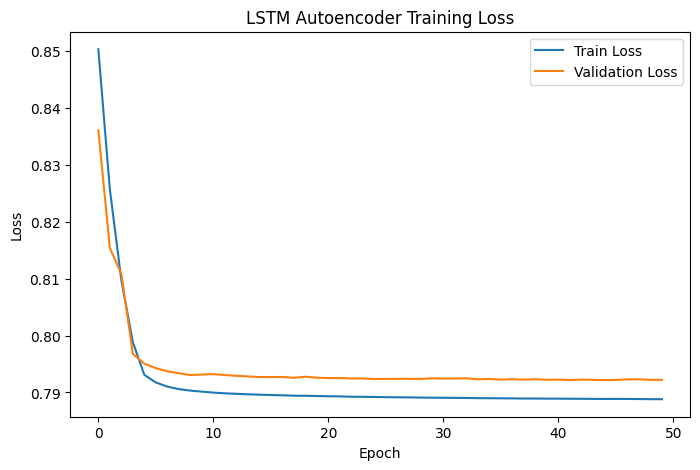

In [5]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    X_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Autoencoder Training Loss")
plt.legend()
plt.show()

In [6]:
def calculate_mse(model, X_seq, batch_size=16):
    mse_list = []

    for i in range(0, len(X_seq), batch_size):
        batch = X_seq[i:i + batch_size]
        batch_pred = model.predict(batch, verbose=0)
        batch_mse = np.mean(np.square(batch - batch_pred), axis=(1, 2))
        mse_list.extend(batch_mse)

    return np.array(mse_list)


batch_size = 16

train_mse = calculate_mse(model, X_train_seq, batch_size)
test_mse = calculate_mse(model, X_test_seq, batch_size)
faulty_train_mse = calculate_mse(model, X_faulty_seq, batch_size)

print("Train MSE shape:", train_mse.shape)
print("Test MSE shape:", test_mse.shape)
print("Faulty Train MSE shape:", faulty_train_mse.shape)

print("\nTrain MSE mean:", train_mse.mean())
print("Test MSE mean:", test_mse.mean())
print("Faulty Train MSE mean:", faulty_train_mse.mean())

print("Train MSE percentiles:", np.percentile(train_mse, [50, 75, 90, 95, 99]))
print("Test MSE percentiles:", np.percentile(test_mse, [50, 75, 90, 95, 99]))
print("Faulty Train MSE percentiles:", np.percentile(faulty_train_mse, [50, 75, 90, 95, 99]))

Train MSE shape: (240500,)
Test MSE shape: (470500,)
Faulty Train MSE shape: (9981,)

Train MSE mean: 0.7890135716602771
Test MSE mean: 0.7909465290106706
Faulty Train MSE mean: 211.80394876249363
Train MSE percentiles: [0.7856746  0.83274522 0.87778423 0.90654375 0.96641497]
Test MSE percentiles: [0.78789658 0.8346314  0.87973638 0.90815312 0.96626405]
Faulty Train MSE percentiles: [242.17361877 278.55216163 311.45166518 326.32094888 342.87424348]


In [13]:
threshold = np.percentile(train_mse, 90)
print("Anomaly threshold:", threshold)

train_flags = (train_mse > threshold).astype(int)
test_flags = (test_mse > threshold).astype(int)
faulty_train_flags = (faulty_train_mse > threshold).astype(int)

train_results = train_seq_meta.copy()
train_results["reconstruction_error"] = train_mse
train_results["is_anomaly"] = train_flags

test_results = test_seq_meta.copy()
test_results["reconstruction_error"] = test_mse
test_results["is_anomaly"] = test_flags

faulty_train_results = faulty_seq_meta.copy()
faulty_train_results["reconstruction_error"] = faulty_train_mse
faulty_train_results["is_anomaly"] = faulty_train_flags

train_anomalies = train_results[train_results["is_anomaly"] == 1].copy()
test_anomalies = test_results[test_results["is_anomaly"] == 1].copy()
faulty_train_anomalies = faulty_train_results[faulty_train_results["is_anomaly"] == 1].copy()

print("\nNumber of TRAIN anomalies detected:", len(train_anomalies))
print("Number of TEST anomalies detected:", len(test_anomalies))
print("Number of FAULTY TRAIN anomalies detected:", len(faulty_train_anomalies))

Anomaly threshold: 0.8777842292420476

Number of TRAIN anomalies detected: 24050
Number of TEST anomalies detected: 49145
Number of FAULTY TRAIN anomalies detected: 9744



Train Accuracy: 0.9
Test Accuracy: 0.8955472901168969
Faulty Train Accuracy: 0.9762548842801323
Faulty Train Detection Rate: 0.9762548842801323


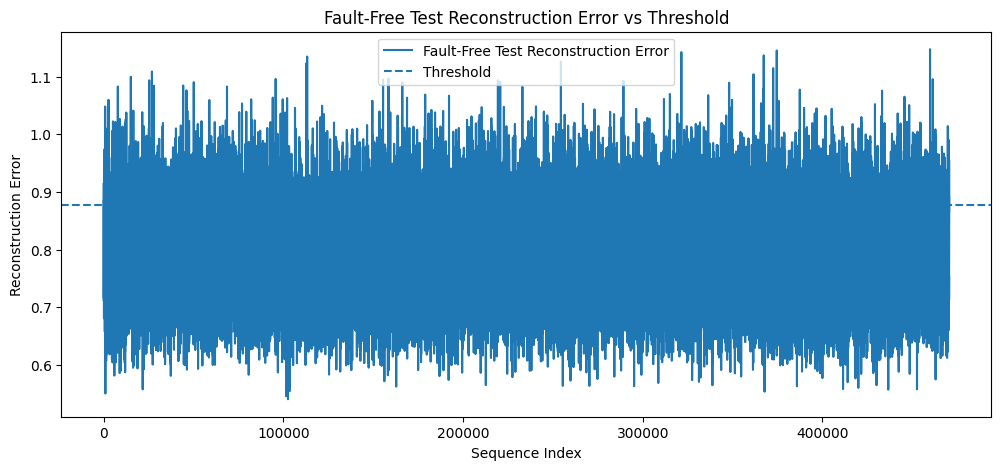

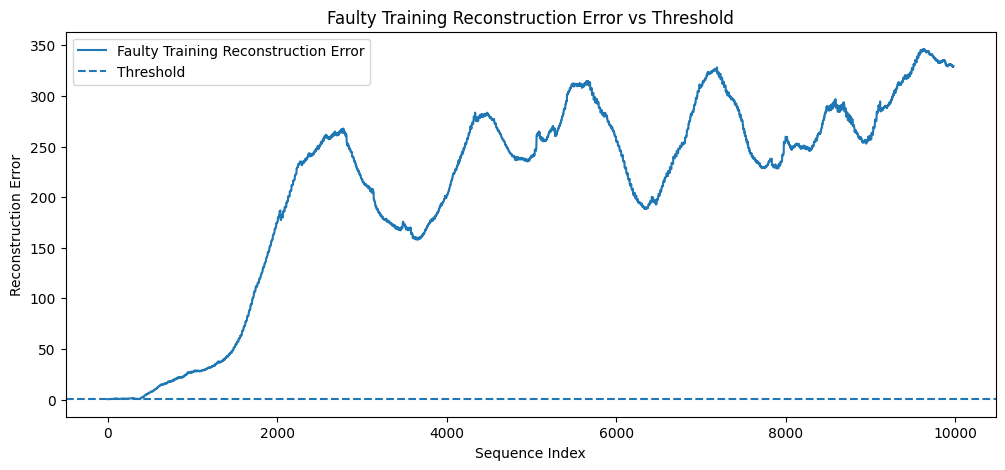

In [14]:
y_train_true = np.zeros(len(train_mse), dtype=int)
y_test_true = np.zeros(len(test_mse), dtype=int)
y_faulty_train_true = np.ones(len(faulty_train_mse), dtype=int)

train_accuracy = accuracy_score(y_train_true, train_flags)
test_accuracy = accuracy_score(y_test_true, test_flags)
faulty_train_accuracy = accuracy_score(y_faulty_train_true, faulty_train_flags)

print("\nTrain Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Faulty Train Accuracy:", faulty_train_accuracy)
print("Faulty Train Detection Rate:", faulty_train_flags.mean())

plt.figure(figsize=(12, 5))
plt.plot(test_mse, label="Fault-Free Test Reconstruction Error")
plt.axhline(y=threshold, linestyle="--", label="Threshold")
plt.xlabel("Sequence Index")
plt.ylabel("Reconstruction Error")
plt.title("Fault-Free Test Reconstruction Error vs Threshold")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(faulty_train_mse, label="Faulty Training Reconstruction Error")
plt.axhline(y=threshold, linestyle="--", label="Threshold")
plt.xlabel("Sequence Index")
plt.ylabel("Reconstruction Error")
plt.title("Faulty Training Reconstruction Error vs Threshold")
plt.legend()
plt.show()

model.save(f"{save_path}/lstm_autoencoder_model.keras")

In [15]:
feature_columns = X_train_scaled_df.columns.tolist()
joblib.dump(feature_columns, f"{save_path}/feature_columns.pkl")

config = {
    "seq_length": seq_length,
    "threshold": float(threshold),
    "batch_size": batch_size,
    "n_features": n_features,
    "timesteps": timesteps,
    "model_type": "LSTM Autoencoder"
}

with open(f"{save_path}/config.json", "w") as f:
    json.dump(config, f, indent=4)

pd.DataFrame(history.history).to_csv(f"{save_path}/training_history.csv", index=False)

joblib.dump(train_mse, f"{save_path}/train_mse.pkl")
joblib.dump(test_mse, f"{save_path}/test_mse.pkl")
joblib.dump(faulty_train_mse, f"{save_path}/faulty_train_mse.pkl")

train_seq_meta.to_pickle(f"{save_path}/train_seq_meta.pkl")
test_seq_meta.to_pickle(f"{save_path}/test_seq_meta.pkl")
faulty_seq_meta.to_pickle(f"{save_path}/faulty_train_seq_meta.pkl")

train_results.to_csv(f"{save_path}/train_results.csv", index=False)
test_results.to_csv(f"{save_path}/test_results.csv", index=False)
faulty_train_results.to_csv(f"{save_path}/faulty_train_results.csv", index=False)

train_results.to_pickle(f"{save_path}/train_results.pkl")
test_results.to_pickle(f"{save_path}/test_results.pkl")
faulty_train_results.to_pickle(f"{save_path}/faulty_train_results.pkl")

train_anomalies.to_csv(f"{save_path}/train_anomalies.csv", index=False)
test_anomalies.to_csv(f"{save_path}/test_anomalies.csv", index=False)
faulty_train_anomalies.to_csv(f"{save_path}/faulty_train_anomalies.csv", index=False)

train_anomalies.to_pickle(f"{save_path}/train_anomalies.pkl")
test_anomalies.to_pickle(f"{save_path}/test_anomalies.pkl")
faulty_train_anomalies.to_pickle(f"{save_path}/faulty_train_anomalies.pkl")

with open(f"{save_path}/model_summary.txt", "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

metrics = {
    "train_accuracy": float(train_accuracy),
    "test_accuracy": float(test_accuracy),
    "faulty_train_accuracy": float(faulty_train_accuracy),
    "faulty_train_detection_rate": float(faulty_train_flags.mean()),
    "train_anomalies": int(len(train_anomalies)),
    "test_anomalies": int(len(test_anomalies)),
    "faulty_train_anomalies": int(len(faulty_train_anomalies))
}

with open(f"{save_path}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("All artifacts saved successfully!")

All artifacts saved successfully!
